In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import skfuzzy as fuzz
from sklearn.preprocessing import StandardScaler, MinMaxScaler

In [2]:
np.random.seed(42)
n = 200

#pendapatan antara 500rb - 10 juta
pendapatan = np.random.randint(500, 10000, n)
#tanggungan antara 1-8 orang(berkorelasi dengan pendapatan)
tanggungan = np.clip(np.random.normal(4 - (pendapatan / 5000), 1.5, n).round(), 1, 8).astype(int)

#gabungkan jadi dataframe
data_bansos = pd.DataFrame({
    'pendapatan_ribu': pendapatan,
    'tanggungan': tanggungan
})

print(data_bansos.head())

   pendapatan_ribu  tanggungan
0             7770           1
1             1360           3
2             5890           4
3             5691           4
4             6234           2


In [3]:
data_bansos.to_csv('dataset_bansos.csv', index=False)

In [4]:
data = pd.read_csv('dataset_bansos.csv')
data.head()

,pendapatan_ribu,tanggungan
0,7770,1
1,1360,3
2,5890,4
3,5691,4
4,6234,2


In [5]:
#preprocess data
X = data[['pendapatan_ribu', 'tanggungan']].values
print(X)

[[7770    1]
 [1360    3]
 [5890    4]
 [5691    4]
 [6234    2]
 [6765    2]
 [ 966    4]
 [4926    4]
 [6078    5]
 [8822    2]
 [2185    5]
 [1269    5]
 [7449    3]
 [2933    1]
 [5811    1]
 [5551    4]
 [6920    1]
 [1684    4]
 [5055    4]
 [3885    3]
 [6896    2]
 [9166    1]
 [9774    3]
 [3058    4]
 [8349    2]
 [2547    5]
 [3247    5]
 [9667    5]
 [ 689    5]
 [3234    3]
 [3505    3]
 [5158    1]
 [2399    4]
 [8234    2]
 [1767    2]
 [2028    4]
 [4056    5]
 [4390    2]
 [9338    1]
 [5893    4]
 [9292    3]
 [8933    7]
 [8013    1]
 [3112    4]
 [7541    3]
 [6735    3]
 [5986    4]
 [7599    2]
 [1275    1]
 [8726    1]
 [3652    5]
 [2085    5]
 [4443    3]
 [8055    3]
 [3573    7]
 [1521    4]
 [4343    3]
 [8489    3]
 [7373    3]
 [6175    2]
 [ 661    5]
 [4797    1]
 [1495    4]
 [8129    2]
 [9967    2]
 [1516    3]
 [8369    1]
 [6939    1]
 [8392    1]
 [7363    2]
 [8416    4]
 [9029    2]
 [1378    5]
 [9768    1]
 [5387    1]
 [5359    2]
 [6831    1]

In [6]:
#feature scaling
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)
print(X_scaled)

[[0.76578108 0.        ]
 [0.08459086 0.33333333]
 [0.56599362 0.5       ]
 [0.54484591 0.5       ]
 [0.60255048 0.16666667]
 [0.65897981 0.16666667]
 [0.04272051 0.5       ]
 [0.46354942 0.5       ]
 [0.58597237 0.66666667]
 [0.87757705 0.16666667]
 [0.17226355 0.66666667]
 [0.0749203  0.66666667]
 [0.73166844 0.33333333]
 [0.25175345 0.        ]
 [0.5575983  0.        ]
 [0.52996812 0.5       ]
 [0.67545165 0.        ]
 [0.11902232 0.5       ]
 [0.47725824 0.5       ]
 [0.35292242 0.33333333]
 [0.67290117 0.16666667]
 [0.9141339  0.        ]
 [0.97874601 0.33333333]
 [0.26503719 0.5       ]
 [0.82731137 0.16666667]
 [0.21073326 0.66666667]
 [0.28512221 0.66666667]
 [0.96737513 0.66666667]
 [0.01328374 0.66666667]
 [0.2837407  0.33333333]
 [0.31253985 0.33333333]
 [0.48820404 0.        ]
 [0.19500531 0.5       ]
 [0.81509033 0.16666667]
 [0.12784272 0.16666667]
 [0.15557917 0.5       ]
 [0.37109458 0.66666667]
 [0.40658874 0.16666667]
 [0.93241233 0.        ]
 [0.56631243 0.5       ]


In [7]:
#terapkan Fuzzy c means clustering
n_clusters = 3 #number cluster
m = 2 # parameter fuzzy

cntr, u, u0, d, jm,p, fpc = fuzz.cluster.cmeans(
    X_scaled.T, n_clusters, m, error = 0.005, maxiter = 1000, init = None
)

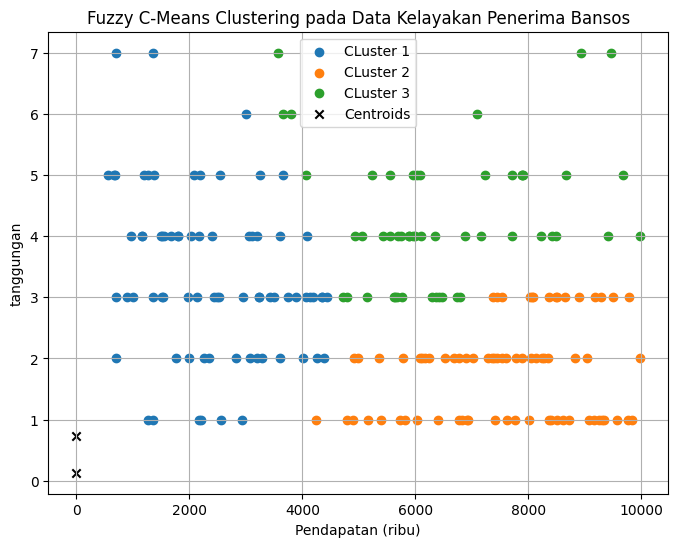

In [8]:
#visualisasi cluster
cluster_membership = np.argmax(u, axis = 0)

plt.figure(figsize=(8,6))
for i in range(n_clusters):
  plt.scatter(X[cluster_membership == i, 0], X[cluster_membership == i, 1], label=f'CLuster {i+1}')

plt.scatter(cntr[0], cntr[1], marker='x', color = 'black', label='Centroids')

plt.title('Fuzzy C-Means Clustering pada Data Kelayakan Penerima Bansos')
plt.xlabel('Pendapatan (ribu)')
plt.ylabel('tanggungan')
plt.legend()
plt.grid(True)
plt.show()

Dataset Summary:
       pendapatan_ribu  tanggungan
count       200.000000  200.000000
mean       4831.110000    3.355000
std        2764.351031    1.893914
min         689.000000    1.000000
25%        2275.750000    2.000000
50%        4672.000000    3.000000
75%        7097.750000    5.000000
max       10000.000000    7.000000

First 10 rows:
   pendapatan_ribu  tanggungan
0             1444           6
1             9537           1
2             8517           1
3             4738           2
4             2715           6
5             1499           4
6             8246           1
7             3430           4
8             3910           3
9             8678           2


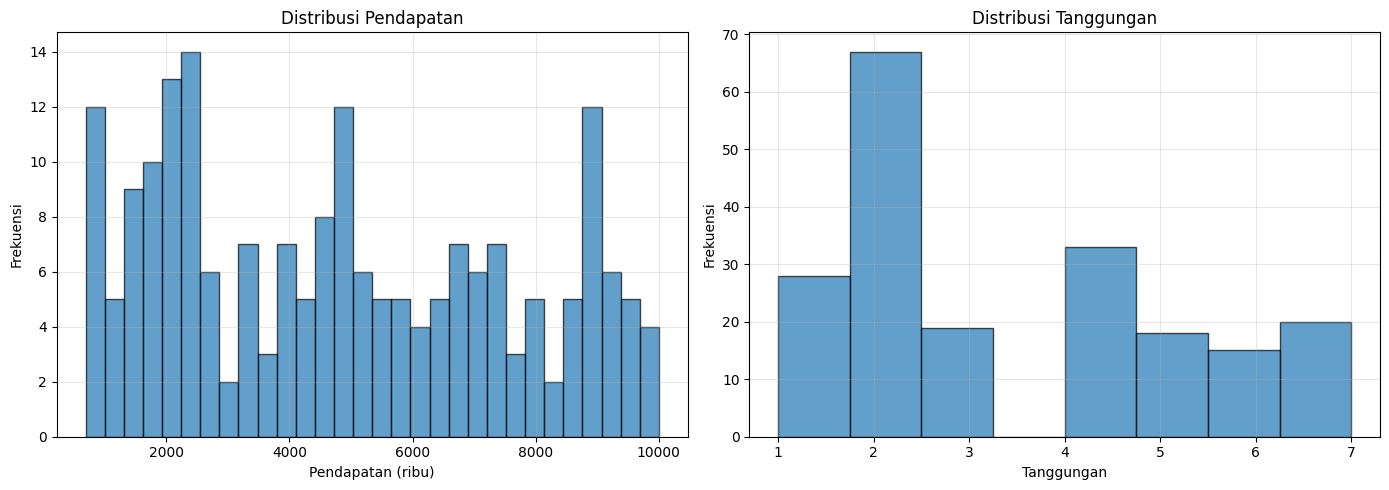

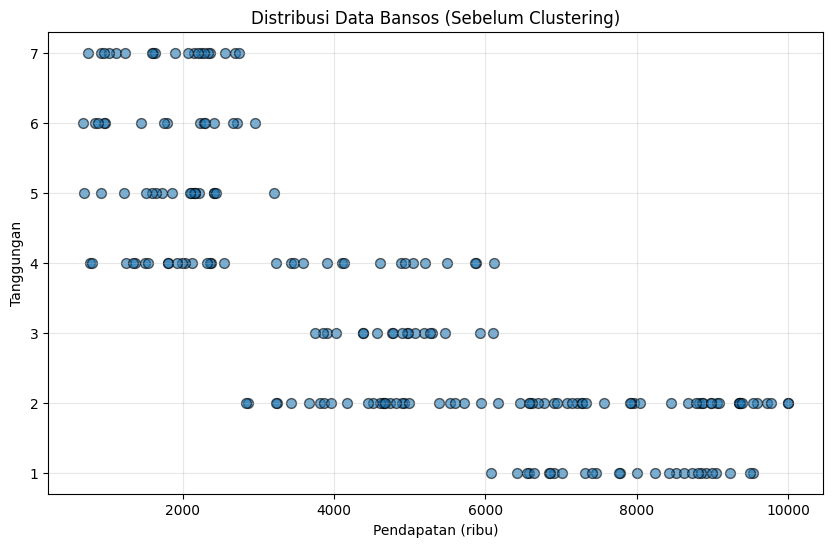

In [9]:
# Buat dataset dengan 3 kelompok yang lebih jelas
np.random.seed(42)

# Cluster 1: Pendapatan Tinggi, Tanggungan Rendah (TIDAK PRIORITAS)
n1 = 70
pendapatan_c1 = np.random.randint(6000, 10000, n1)
tanggungan_c1 = np.random.randint(1, 3, n1)

# Cluster 2: Pendapatan Rendah, Tanggungan Tinggi (PRIORITAS TINGGI)
n2 = 70
pendapatan_c2 = np.random.randint(500, 3000, n2)
tanggungan_c2 = np.random.randint(4, 8, n2)

# Cluster 3: Pendapatan Sedang, Tanggungan Sedang (PRIORITAS SEDANG)
n3 = 60
pendapatan_c3 = np.random.randint(3000, 6000, n3)
tanggungan_c3 = np.random.randint(2, 5, n3)

# Gabungkan semua cluster
pendapatan = np.concatenate([pendapatan_c1, pendapatan_c2, pendapatan_c3])
tanggungan = np.concatenate([tanggungan_c1, tanggungan_c2, tanggungan_c3])

# Tambahkan sedikit noise untuk membuat lebih realistis
pendapatan = pendapatan + np.random.normal(0, 200, len(pendapatan))
pendapatan = np.clip(pendapatan, 500, 10000)

# Buat dataframe
data_bansos = pd.DataFrame({
    'pendapatan_ribu': pendapatan.astype(int),
    'tanggungan': tanggungan
})

# Shuffle data
data_bansos = data_bansos.sample(frac=1, random_state=42).reset_index(drop=True)

print("Dataset Summary:")
print(data_bansos.describe())
print("\nFirst 10 rows:")
print(data_bansos.head(10))

# Visualisasi distribusi data
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(data_bansos['pendapatan_ribu'], bins=30, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Pendapatan (ribu)')
axes[0].set_ylabel('Frekuensi')
axes[0].set_title('Distribusi Pendapatan')
axes[0].grid(True, alpha=0.3)

axes[1].hist(data_bansos['tanggungan'], bins=8, edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Tanggungan')
axes[1].set_ylabel('Frekuensi')
axes[1].set_title('Distribusi Tanggungan')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Scatter plot data mentah
plt.figure(figsize=(10, 6))
plt.scatter(data_bansos['pendapatan_ribu'], data_bansos['tanggungan'], 
            alpha=0.6, s=50, edgecolors='black')
plt.xlabel('Pendapatan (ribu)')
plt.ylabel('Tanggungan')
plt.title('Distribusi Data Bansos (Sebelum Clustering)')
plt.grid(True, alpha=0.3)
plt.show()

Fuzzy Partition Coefficient (FPC): 0.8317
Semakin mendekati 1, semakin baik clustering


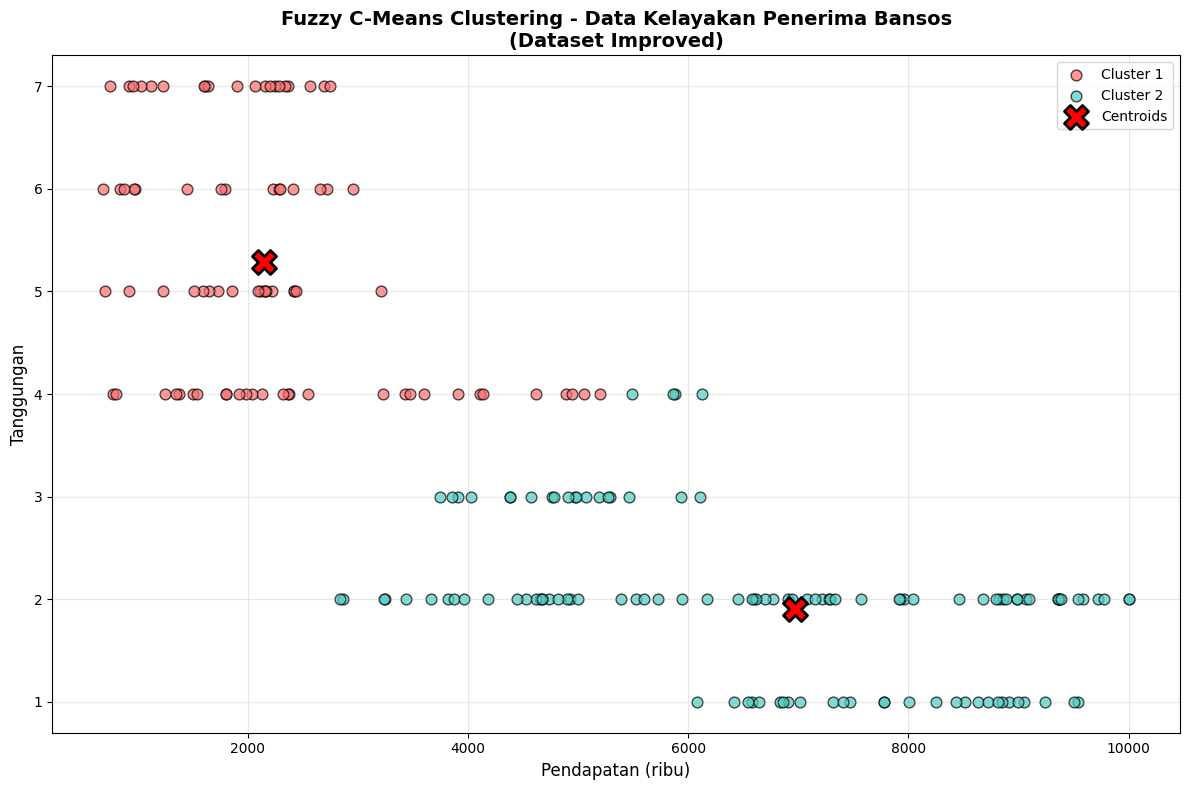


=== ANALISIS CLUSTER ===

Cluster 1:
  Jumlah data: 82
  Rata-rata pendapatan: 2175 ribu
  Rata-rata tanggungan: 5.3 orang
  Centroid: Pendapatan=2144, Tanggungan=5.3

Cluster 2:
  Jumlah data: 118
  Rata-rata pendapatan: 6677 ribu
  Rata-rata tanggungan: 2.0 orang
  Centroid: Pendapatan=6972, Tanggungan=1.9


In [10]:


# Load data
data = pd.read_csv('dataset_bansos_improved.csv')

# Preprocess data
X = data[['pendapatan_ribu', 'tanggungan']].values

# Feature scaling
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Terapkan Fuzzy C-Means Clustering
n_clusters = 2
m = 2

cntr, u, u0, d, jm, p, fpc = fuzz.cluster.cmeans(
    X_scaled.T, n_clusters, m, error=0.005, maxiter=1000, init=None
)

print(f"Fuzzy Partition Coefficient (FPC): {fpc:.4f}")
print("Semakin mendekati 1, semakin baik clustering")

# Visualisasi cluster dengan warna yang lebih jelas
cluster_membership = np.argmax(u, axis=0)

plt.figure(figsize=(12, 8))
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']
labels = ['Cluster 1', 'Cluster 2', 'Cluster 3']

for i in range(n_clusters):
    cluster_data = X[cluster_membership == i]
    plt.scatter(cluster_data[:, 0], cluster_data[:, 1], 
                c=colors[i], label=labels[i], s=60, alpha=0.7, edgecolors='black')

# Transform centroids kembali ke skala asli
cntr_original = scaler.inverse_transform(cntr)
plt.scatter(cntr_original[:, 0], cntr_original[:, 1], 
            marker='X', s=300, color='red', edgecolors='black', 
            linewidths=2, label='Centroids', zorder=5)

plt.title('Fuzzy C-Means Clustering - Data Kelayakan Penerima Bansos\n(Dataset Improved)', 
          fontsize=14, fontweight='bold')
plt.xlabel('Pendapatan (ribu)', fontsize=12)
plt.ylabel('Tanggungan', fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Analisis setiap cluster
print("\n=== ANALISIS CLUSTER ===")
for i in range(n_clusters):
    cluster_data = data[cluster_membership == i]
    print(f"\nCluster {i+1}:")
    print(f"  Jumlah data: {len(cluster_data)}")
    print(f"  Rata-rata pendapatan: {cluster_data['pendapatan_ribu'].mean():.0f} ribu")
    print(f"  Rata-rata tanggungan: {cluster_data['tanggungan'].mean():.1f} orang")
    print(f"  Centroid: Pendapatan={cntr_original[i, 0]:.0f}, Tanggungan={cntr_original[i, 1]:.1f}")

Jumlah data ambigu: 9 dari 200 data
Persentase data ambigu: 4.50%


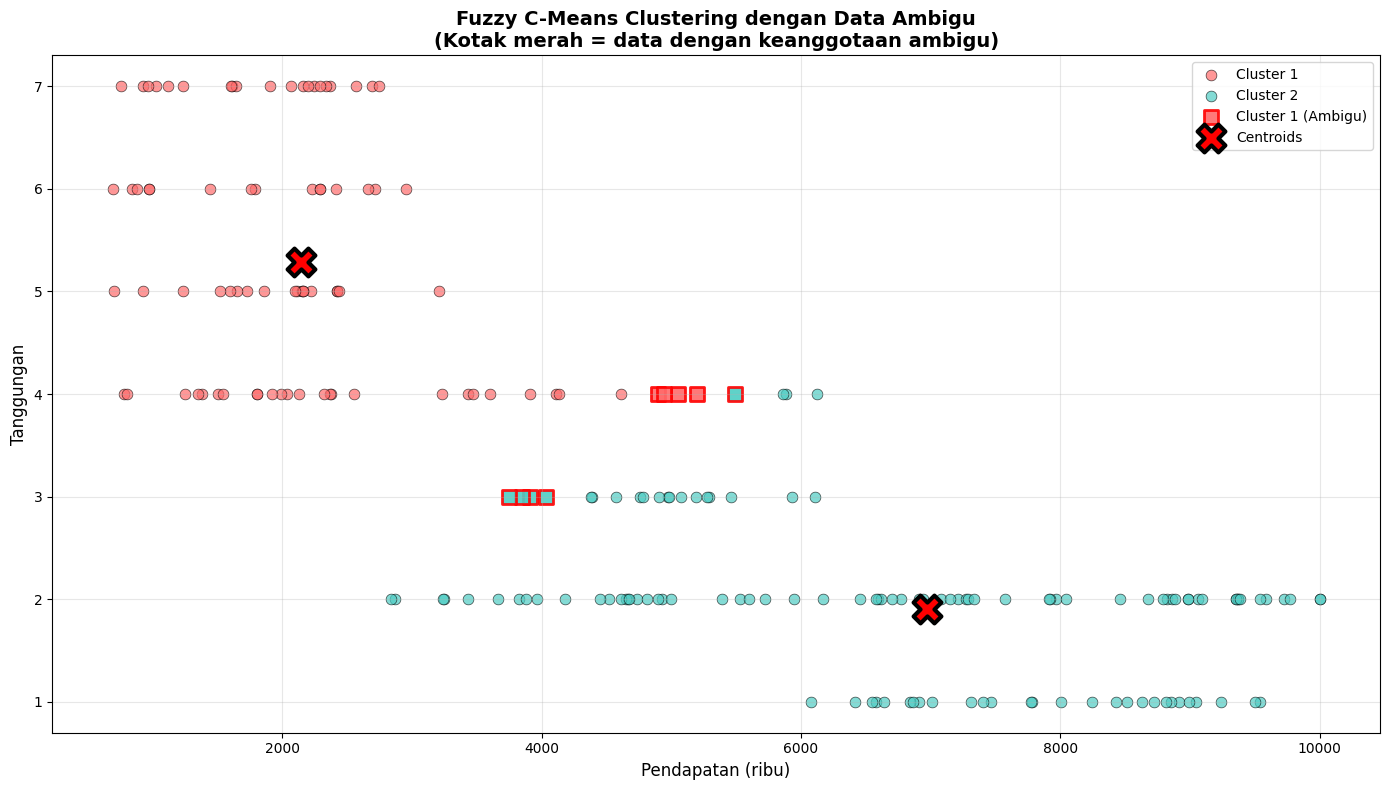


=== ANALISIS DATA AMBIGU ===

Cluster 1 - Data Ambigu:
  Jumlah: 4
  Rata-rata pendapatan: 5022 ribu
  Rata-rata tanggungan: 4.0 orang

Cluster 2 - Data Ambigu:
  Jumlah: 5
  Rata-rata pendapatan: 4206 ribu
  Rata-rata tanggungan: 3.2 orang

=== 10 DATA PALING AMBIGU ===

Data index 51:
  Pendapatan: 5199 ribu
  Tanggungan: 4 orang
  Cluster terpilih: 1
  Derajat keanggotaan:
    Cluster 1: 0.5068
    Cluster 2: 0.4932
  Selisih membership: 0.0136

Data index 193:
  Pendapatan: 3748 ribu
  Tanggungan: 3 orang
  Cluster terpilih: 2
  Derajat keanggotaan:
    Cluster 1: 0.4662
    Cluster 2: 0.5338
  Selisih membership: 0.0675

Data index 58:
  Pendapatan: 5050 ribu
  Tanggungan: 4 orang
  Cluster terpilih: 1
  Derajat keanggotaan:
    Cluster 1: 0.5338
    Cluster 2: 0.4662
  Selisih membership: 0.0676

Data index 174:
  Pendapatan: 5488 ribu
  Tanggungan: 4 orang
  Cluster terpilih: 2
  Derajat keanggotaan:
    Cluster 1: 0.4567
    Cluster 2: 0.5433
  Selisih membership: 0.0867

Data

In [11]:
# Analisis derajat keanggotaan fuzzy
cluster_membership = np.argmax(u, axis=0)

# Hitung selisih antara derajat keanggotaan tertinggi dan kedua tertinggi
membership_sorted = np.sort(u, axis=0)[::-1]  # Sort descending
highest_membership = membership_sorted[0]
second_highest_membership = membership_sorted[1]
membership_difference = highest_membership - second_highest_membership

# Tentukan threshold untuk data ambigu (selisih < 0.2 artinya ambigu)
ambiguous_threshold = 0.2
ambiguous_points = membership_difference < ambiguous_threshold

print(f"Jumlah data ambigu: {np.sum(ambiguous_points)} dari {len(ambiguous_points)} data")
print(f"Persentase data ambigu: {np.sum(ambiguous_points)/len(ambiguous_points)*100:.2f}%")

# Visualisasi dengan highlight data ambigu
plt.figure(figsize=(14, 8))

# Plot data normal per cluster
for i in range(n_clusters):
    cluster_mask = (cluster_membership == i) & (~ambiguous_points)
    cluster_data = X[cluster_mask]
    plt.scatter(cluster_data[:, 0], cluster_data[:, 1], 
                c=colors[i], label=f'Cluster {i+1}', 
                s=60, alpha=0.7, edgecolors='black', linewidths=0.5)

# Plot data ambigu dengan marker berbeda
for i in range(n_clusters):
    ambiguous_cluster_mask = (cluster_membership == i) & ambiguous_points
    ambiguous_cluster_data = X[ambiguous_cluster_mask]
    if len(ambiguous_cluster_data) > 0:
        plt.scatter(ambiguous_cluster_data[:, 0], ambiguous_cluster_data[:, 1], 
                    c=colors[i], marker='s', s=100, alpha=0.9, 
                    edgecolors='red', linewidths=2,
                    label=f'Cluster {i+1} (Ambigu)' if i == 0 else '')

# Plot centroids
cntr_original = scaler.inverse_transform(cntr)
plt.scatter(cntr_original[:, 0], cntr_original[:, 1], 
            marker='X', s=400, color='red', edgecolors='black', 
            linewidths=3, label='Centroids', zorder=5)

plt.title('Fuzzy C-Means Clustering dengan Data Ambigu\n(Kotak merah = data dengan keanggotaan ambigu)', 
          fontsize=14, fontweight='bold')
plt.xlabel('Pendapatan (ribu)', fontsize=12)
plt.ylabel('Tanggungan', fontsize=12)
plt.legend(fontsize=10, loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Analisis detail data ambigu
print("\n=== ANALISIS DATA AMBIGU ===")
for i in range(n_clusters):
    ambiguous_cluster_mask = (cluster_membership == i) & ambiguous_points
    ambiguous_cluster_data = data[ambiguous_cluster_mask]
    
    if len(ambiguous_cluster_data) > 0:
        print(f"\nCluster {i+1} - Data Ambigu:")
        print(f"  Jumlah: {len(ambiguous_cluster_data)}")
        print(f"  Rata-rata pendapatan: {ambiguous_cluster_data['pendapatan_ribu'].mean():.0f} ribu")
        print(f"  Rata-rata tanggungan: {ambiguous_cluster_data['tanggungan'].mean():.1f} orang")

# Detail 10 data paling ambigu
print("\n=== 10 DATA PALING AMBIGU ===")
most_ambiguous_indices = np.argsort(membership_difference)[:10]

for idx in most_ambiguous_indices:
    cluster_id = cluster_membership[idx]
    print(f"\nData index {idx}:")
    print(f"  Pendapatan: {data.iloc[idx]['pendapatan_ribu']} ribu")
    print(f"  Tanggungan: {data.iloc[idx]['tanggungan']} orang")
    print(f"  Cluster terpilih: {cluster_id + 1}")
    print(f"  Derajat keanggotaan:")
    for c in range(n_clusters):
        print(f"    Cluster {c+1}: {u[c, idx]:.4f}")
    print(f"  Selisih membership: {membership_difference[idx]:.4f}")

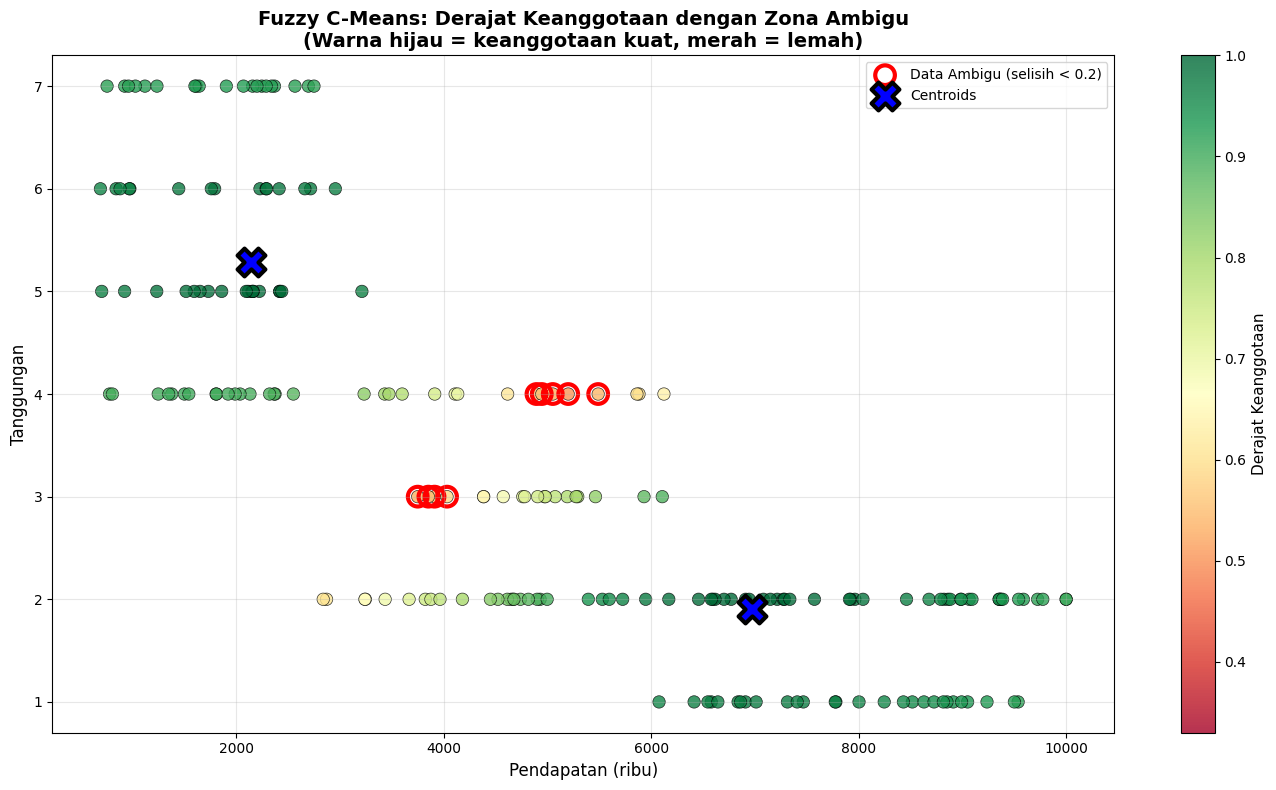

In [12]:
# Visualisasi dengan boundary dan gradien warna berdasarkan tingkat keanggotaan
plt.figure(figsize=(14, 8))

# Plot setiap data dengan intensity warna berdasarkan derajat keanggotaan
for i in range(n_clusters):
    cluster_mask = cluster_membership == i
    cluster_data = X[cluster_mask]
    cluster_membership_values = highest_membership[cluster_mask]
    
    scatter = plt.scatter(cluster_data[:, 0], cluster_data[:, 1], 
                         c=cluster_membership_values, cmap='RdYlGn', 
                         vmin=0.33, vmax=1.0, s=80, alpha=0.8,
                         edgecolors='black', linewidths=0.5)

# Tambahkan colorbar
cbar = plt.colorbar(scatter)
cbar.set_label('Derajat Keanggotaan', fontsize=11)

# Highlight data ambigu dengan circle
ambiguous_data = X[ambiguous_points]
plt.scatter(ambiguous_data[:, 0], ambiguous_data[:, 1], 
            facecolors='none', edgecolors='red', 
            s=200, linewidths=3, label='Data Ambigu (selisih < 0.2)')

# Plot centroids
cntr_original = scaler.inverse_transform(cntr)
plt.scatter(cntr_original[:, 0], cntr_original[:, 1], 
            marker='X', s=400, color='blue', edgecolors='black', 
            linewidths=3, label='Centroids', zorder=5)

plt.title('Fuzzy C-Means: Derajat Keanggotaan dengan Zona Ambigu\n(Warna hijau = keanggotaan kuat, merah = lemah)', 
          fontsize=14, fontweight='bold')
plt.xlabel('Pendapatan (ribu)', fontsize=12)
plt.ylabel('Tanggungan', fontsize=12)
plt.legend(fontsize=10, loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()